In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
time_data = pd.read_csv('time_series.csv')
time_data.head(20)

,date,value
0,2016-05-09,1201
1,2016-05-10,2329
2,2016-05-11,1716
3,2016-05-12,10539
4,2016-05-13,6933
5,2016-05-14,3127
6,2016-05-15,2927
7,2016-05-16,2591
8,2016-05-17,3403
9,2016-05-18,5410


In [4]:
times_series_data = time_data[(time_data["value"] >= time_data["value"].quantile(0.025)) & (time_data["value"] <= time_data["value"].quantile(0.975))]
times_series_data

,date,value
10,2016-05-19,19736
17,2016-05-26,18060
18,2016-05-27,19997
19,2016-05-28,19044
20,2016-05-29,20325
...,...,...
1294,2019-11-24,138875
1299,2019-11-29,171584
1300,2019-11-30,141161
1301,2019-12-01,142918


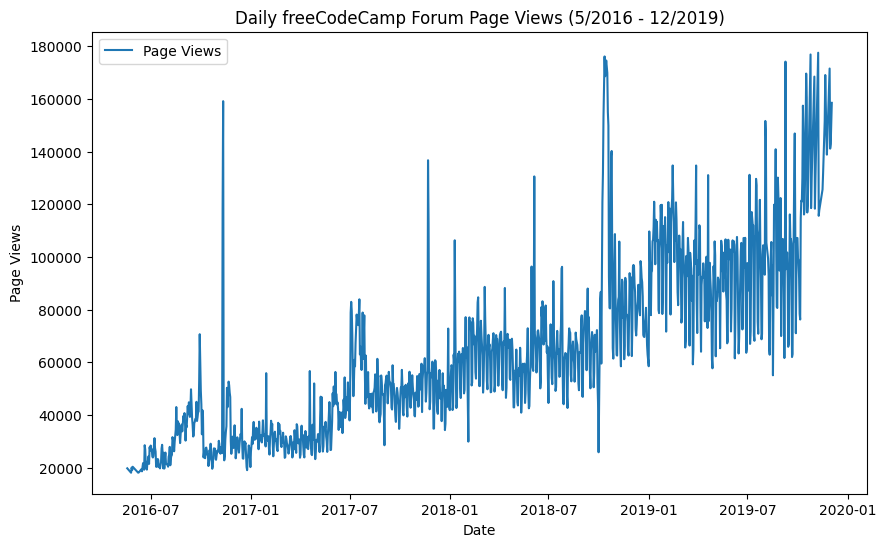

In [6]:

def draw_line_plot():
    fig, ax = plt.subplots(figsize=(10, 6))

    times_series_data_plot = times_series_data.copy();
    times_series_data_plot['date'] = pd.to_datetime(times_series_data_plot['date'])


    times_series_data_date_filtered = times_series_data_plot[(times_series_data_plot['date'] >= "2016-05-01") & (times_series_data_plot['date'] <= "2019-12-30")]

    # Plot the data
    ax.plot(times_series_data_date_filtered["date"], times_series_data_date_filtered["value"], label="Page Views")

    # Set title and labels
    ax.set(title="Daily freeCodeCamp Forum Page Views (5/2016 - 12/2019)",
           xlabel="Date",
           ylabel="Page Views")

    # Add legend
    ax.legend()

    # Show plot
    plt.show()

draw_line_plot()

    year  month                          date          value
0   2016      5 2016-05-25 19:12:00.000000000   19432.400000
1   2016      6 2016-06-20 02:31:34.736841984   21875.105263
2   2016      7 2016-07-14 20:34:17.142857216   24109.678571
3   2016      8 2016-08-16 00:00:00.000000000   31049.193548
4   2016      9 2016-09-15 12:00:00.000000000   41476.866667
5   2016     10 2016-10-16 00:00:00.000000000   27398.322581
6   2016     11 2016-11-15 12:00:00.000000000   40448.633333
7   2016     12 2016-12-16 00:00:00.000000000   27832.419355
8   2017      1 2017-01-16 00:00:00.000000000   32785.161290
9   2017      2 2017-02-14 12:00:00.000000000   31113.071429
10  2017      3 2017-03-16 00:00:00.000000000   29369.096774
11  2017      4 2017-04-15 12:00:00.000000000   30878.733333
12  2017      5 2017-05-16 00:00:00.000000000   34244.290323
13  2017      6 2017-06-15 12:00:00.000000000   43577.500000
14  2017      7 2017-07-16 00:00:00.000000000   65806.838710
15  2017      8 2017-08-

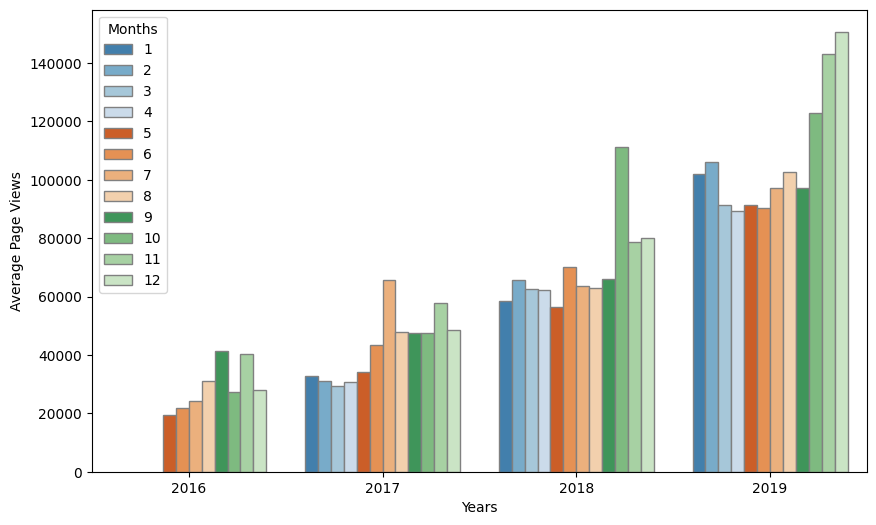

In [ ]:
def draw_bar_plot():
    times_series_data_bar = times_series_data.copy()
    times_series_data_bar['date'] = pd.to_datetime(times_series_data_bar['date'])

    times_series_data_bar['year'] = times_series_data_bar['date'].dt.year
    times_series_data_bar['month'] = times_series_data_bar['date'].dt.month

    times_series_data_bar = times_series_data_bar.groupby(['year', 'month']).agg('mean').reset_index()

    print(times_series_data_bar.head(30))


    plt.subplots(figsize=(10, 6))

    sns.barplot(
        x="year",
        y="value",
        hue="month",
        data=times_series_data_bar,
        palette="tab20c",
        ec="grey"
    )

    plt.xlabel('Years')
    plt.ylabel('Average Page Views')
    plt.legend(title='Months', loc='upper left')
    

draw_bar_plot()
    

         date  value  year  month
10 2016-05-19  19736  2016      5
17 2016-05-26  18060  2016      5
18 2016-05-27  19997  2016      5
19 2016-05-28  19044  2016      5
20 2016-05-29  20325  2016      5
29 2016-06-07  18335  2016      6
30 2016-06-08  18072  2016      6
31 2016-06-09  18139  2016      6
36 2016-06-14  19395  2016      6
37 2016-06-15  18584  2016      6


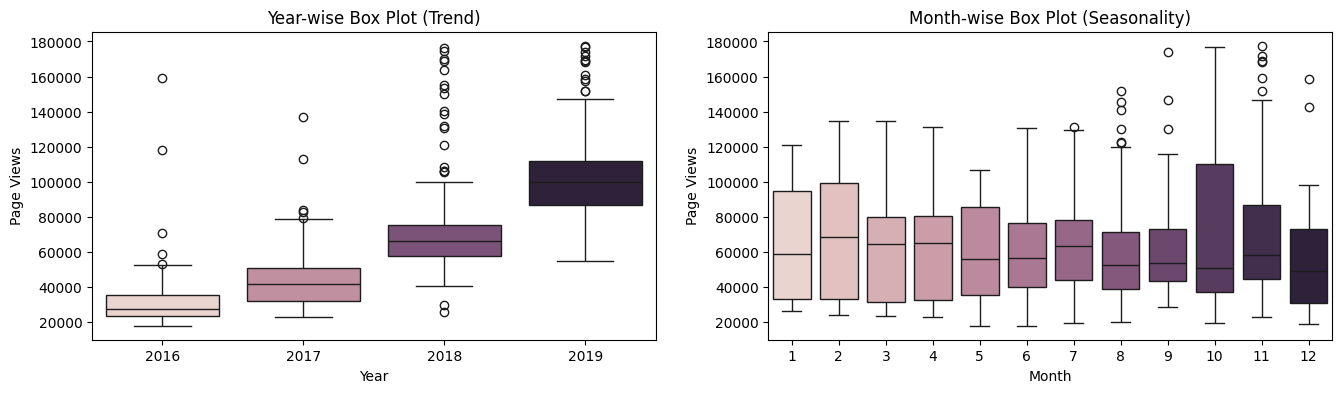

In [ ]:
def draw_box_plot():
    fig, (ax0, ax1) = plt.subplots(nrows=1, 
                               ncols=2,  
                               figsize=(16, 4))
    
    times_series_data_box = times_series_data.copy()
    times_series_data_box['date'] = pd.to_datetime(times_series_data_box['date'])

    times_series_data_box['year'] = times_series_data_box['date'].dt.year
    times_series_data_box['month'] = times_series_data_box['date'].dt.month

    print(times_series_data_box.head(10))

    sns.boxplot(x="year", y="value", data=times_series_data_box, hue='year', ax=ax0)
    ax0.set_title('Year-wise Box Plot (Trend)')
    ax0.set_xlabel('Year')
    ax0.set_ylabel('Page Views')
    ax0.legend().remove()
    

    sns.boxplot(x="month", y="value", data=times_series_data_box, hue='month',ax=ax1)
    ax1.set_title('Month-wise Box Plot (Seasonality)')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Page Views')
    ax1.legend().remove()


draw_box_plot()


    